In [167]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

In [168]:
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Check shape
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [169]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [170]:
# X_train = X_train.reshape(-1, 28*28)
# X_test = X_test.reshape(-1, 28*28)

In [171]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

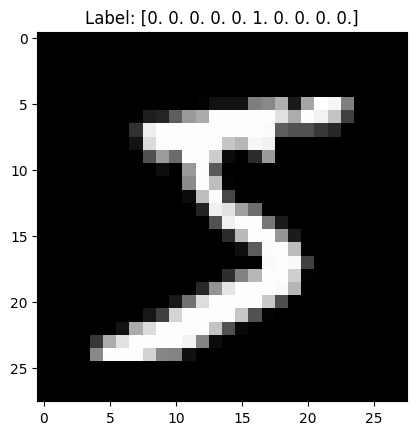

In [172]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [140]:
model1 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(64, activation='sigmoid'),    # smaller
    Dense(32, activation='sigmoid'),    # smaller

    Dense(10, activation='softmax')
])

In [143]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h1 = model1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8913 - loss: 0.3641 - val_accuracy: 0.9038 - val_loss: 0.3400
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8933 - loss: 0.3497 - val_accuracy: 0.9005 - val_loss: 0.3230
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8992 - loss: 0.3288 - val_accuracy: 0.9056 - val_loss: 0.3129
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9089 - loss: 0.2967 - val_accuracy: 0.9134 - val_loss: 0.2852
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9061 - loss: 0.3067 - val_accuracy: 0.9063 - val_loss: 0.3024
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9078 - loss: 0.3013 - val_accuracy: 0.9068 - val_loss: 0.3003
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9142 - loss: 0.2796 - val_accuracy: 0.9152 - val_loss: 0.2695
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9142 - loss: 0.2779 - 

In [173]:
model2 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='sigmoid'),   # larger
    Dense(64, activation='sigmoid'),    # larger

    Dense(10, activation='softmax')
])

In [174]:
model2.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = model2.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9293 - loss: 0.2362 - val_accuracy: 0.9627 - val_loss: 0.1296
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9625 - loss: 0.1231 - val_accuracy: 0.9611 - val_loss: 0.1272
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9674 - loss: 0.1064 - val_accuracy: 0.9618 - val_loss: 0.1248
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9717 - loss: 0.0907 - val_accuracy: 0.9638 - val_loss: 0.1227
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9716 - loss: 0.0899 - val_accuracy: 0.9683 - val_loss: 0.1078


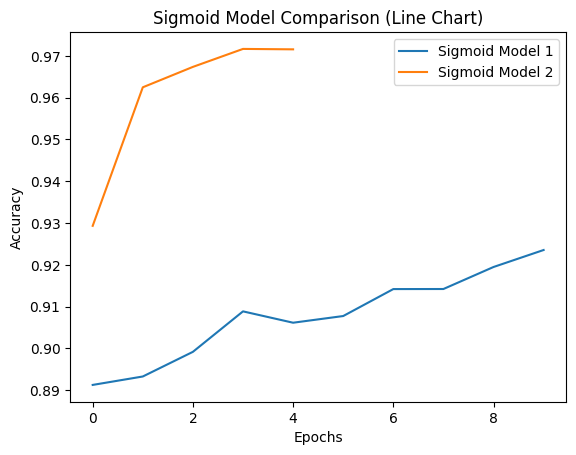

In [175]:
import matplotlib.pyplot as plt

# Plot training accuracy
plt.plot(h1.history['accuracy'], label='Sigmoid Model 1')
plt.plot(h2.history['accuracy'], label='Sigmoid Model 2')


# Labels
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Sigmoid Model Comparison (Line Chart)')
plt.legend()

plt.show()

In [176]:
acc1 = model1.evaluate(X_test, y_test)[1]
acc2 = model2.evaluate(X_test, y_test)[1]

print("Sigmoid Model 1 Accuracy:", acc1)
print("Sigmoid Model 2 Accuracy:", acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9366 - loss: 0.2212
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9683 - loss: 0.1078
Sigmoid Model 1 Accuracy: 0.9366000294685364
Sigmoid Model 2 Accuracy: 0.9682999849319458


In [189]:
model_relu1 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(10, activation='softmax')
])

In [190]:
model_relu1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h_relu1 = model_relu1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9149 - loss: 0.2945 - val_accuracy: 0.9533 - val_loss: 0.1565
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9600 - loss: 0.1341 - val_accuracy: 0.9628 - val_loss: 0.1196
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9697 - loss: 0.0999 - val_accuracy: 0.9668 - val_loss: 0.1081
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9755 - loss: 0.0795 - val_accuracy: 0.9690 - val_loss: 0.1018
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9799 - loss: 0.0650 - val_accuracy: 0.9714 - val_loss: 0.0975
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0565 - val_accuracy: 0.9714 - val_loss: 0.0961
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9849 - loss: 0.0467 - val_accuracy: 0.9715 - val_loss: 0.1001
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0405 - 

In [191]:
model_relu2 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

In [192]:
model_relu2.compile(optimizer=Adam(learning_rate=0.02), loss='categorical_crossentropy', metrics=['accuracy'])
h_relu2 = model_relu2.fit(X_train, y_train, epochs=6, validation_data=(X_test, y_test))

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8989 - loss: 0.3637 - val_accuracy: 0.9374 - val_loss: 0.2605
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9344 - loss: 0.2631 - val_accuracy: 0.9270 - val_loss: 0.3277
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9440 - loss: 0.2381 - val_accuracy: 0.9470 - val_loss: 0.2180
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9472 - loss: 0.2282 - val_accuracy: 0.9465 - val_loss: 0.2482
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9522 - loss: 0.2074 - val_accuracy: 0.9412 - val_loss: 0.2675
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9546 - loss: 0.1956 - val_accuracy: 0.9444 - val_loss: 0.2449


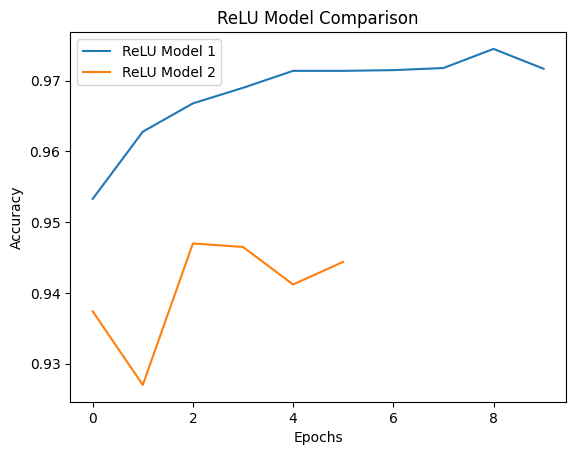

In [193]:
import matplotlib.pyplot as plt

# Validation accuracy comparison
plt.plot(h_relu1.history['val_accuracy'], label='ReLU Model 1')
plt.plot(h_relu2.history['val_accuracy'], label='ReLU Model 2')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ReLU Model Comparison')
plt.legend()

plt.show()

In [194]:
acc_relu1 = model_relu1.evaluate(X_test, y_test)[1]
acc_relu2 = model_relu2.evaluate(X_test, y_test)[1]

print("ReLU Model 1 Accuracy:", acc_relu1)
print("ReLU Model 2 Accuracy:", acc_relu2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1095
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9444 - loss: 0.2449
ReLU Model 1 Accuracy: 0.9717000126838684
ReLU Model 2 Accuracy: 0.9444000124931335


In [195]:
model_tanh1 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),

    Dense(10, activation='softmax')
])

In [196]:
model_tanh1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h_tanh1 = model_tanh1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9154 - loss: 0.3060 - val_accuracy: 0.9496 - val_loss: 0.1712
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9579 - loss: 0.1409 - val_accuracy: 0.9614 - val_loss: 0.1245
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9691 - loss: 0.1004 - val_accuracy: 0.9649 - val_loss: 0.1125
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9762 - loss: 0.0775 - val_accuracy: 0.9688 - val_loss: 0.1031
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9810 - loss: 0.0619 - val_accuracy: 0.9698 - val_loss: 0.0983
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9844 - loss: 0.0517 - val_accuracy: 0.9715 - val_loss: 0.0980
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9863 - loss: 0.0436 - val_accuracy: 0.9713 - val_loss: 0.0984
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9883 - loss: 0.0372 - 

In [197]:
model_tanh2 = Sequential([
    Flatten(input_shape=(28,28)),

    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),

    Dense(10, activation='softmax')
])

In [198]:
model_tanh2.compile(optimizer=Adam(learning_rate=0.04), loss='categorical_crossentropy', metrics=['accuracy'])
h_tanh2 = model_tanh2.fit(X_train, y_train, epochs=4, validation_data=(X_test, y_test))

Epoch 1/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6148 - loss: 1.2000 - val_accuracy: 0.7180 - val_loss: 1.0350
Epoch 2/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6489 - loss: 1.1383 - val_accuracy: 0.7060 - val_loss: 0.9766
Epoch 3/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6497 - loss: 1.1365 - val_accuracy: 0.7043 - val_loss: 0.9564
Epoch 4/4
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6711 - loss: 1.0632 - val_accuracy: 0.6791 - val_loss: 1.0030


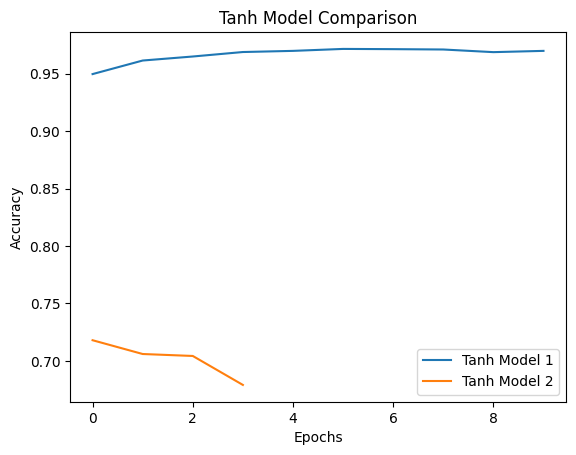

In [199]:
import matplotlib.pyplot as plt

plt.plot(h_tanh1.history['val_accuracy'], label='Tanh Model 1')
plt.plot(h_tanh2.history['val_accuracy'], label='Tanh Model 2')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Tanh Model Comparison')
plt.legend()

plt.show()

In [200]:
acc_tanh1 = model_tanh1.evaluate(X_test, y_test)[1]
acc_tanh2 = model_tanh2.evaluate(X_test, y_test)[1]

print("Tanh Model 1 Accuracy:", acc_tanh1)
print("Tanh Model 2 Accuracy:", acc_tanh2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.1050
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6791 - loss: 1.0030
Tanh Model 1 Accuracy: 0.9697999954223633
Tanh Model 2 Accuracy: 0.679099977016449


In [202]:
print("Sigmoid Accuracy:", model1.evaluate(X_test, y_test)[1])
print("Sigmoid2 Accuracy:", model2.evaluate(X_test, y_test)[1])
print("ReLU Accuracy:", model_relu1.evaluate(X_test, y_test)[1])
print("ReLU2 Accuracy:", model_relu2.evaluate(X_test, y_test)[1])
print("Tanh Accuracy:", model_tanh1.evaluate(X_test, y_test)[1])
print("Tanh2 Accuracy:", model_tanh2.evaluate(X_test, y_test)[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9366 - loss: 0.2212
Sigmoid Accuracy: 0.9366000294685364
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9683 - loss: 0.1078
Sigmoid2 Accuracy: 0.9682999849319458
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1095
ReLU Accuracy: 0.9717000126838684
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9444 - loss: 0.2449
ReLU2 Accuracy: 0.9444000124931335
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.1050
Tanh Accuracy: 0.9697999954223633
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6791 - loss: 1.0030
Tanh2 Accuracy: 0.679099977016449
